In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.datasets import make_circles



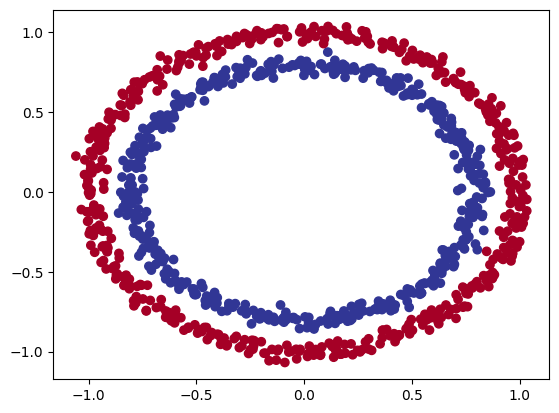

In [ ]:
x,y = make_circles(n_samples=1000,
                   noise=0.03,
                   random_state=42)
plt.scatter(x[:,0],x[:,1],c=y, cmap=plt.cm.RdYlBu);


In [ ]:
# data to tensors
X=torch.from_numpy(x).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

# split the data
from  sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y , train_size=0.8, random_state=42)



In [ ]:
# making the model with non linearity
model=nn.Sequential(nn.Linear(2,10),
                    nn.ReLU(),
                    nn.Linear(10,10),
                    nn.ReLU(),
                    nn.Linear(10,1)

)

In [ ]:
# GPU
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
X_train=X_train.to(device)
X_test=X_test.to(device)
y_train=y_train.to(device)
y_test=y_test.to(device)

In [ ]:
# loss + optimizer
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model.parameters(), lr=0.1)


In [ ]:
from sklearn.metrics import accuracy_score

# Move model to device (GPU if available)
model.to(device)

# training loop
epoch=1000
for i in range(epoch):
  model.train()
  y_logits=model(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))
  loss=loss_fn(y_logits,y_train)
  acc=accuracy_score(y_pred.detach().cpu(),y_train.detach().cpu())
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    X_test = X_test.to(device)
    y_test = y_test.to(device)
    test_logits=model(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))
    test_loss=loss_fn(test_logits,y_test)
    test_acc=accuracy_score(test_pred.detach().cpu(),y_test.detach().cpu())
    if i % 100 == 0:
      print(f"Epoch: {i} | Loss: {loss:.4f} | Acc: {acc:.2f} | Test_loss: {test_loss:.4f} | Test Acc {test_acc:.2f}%")

Epoch: 0 | Loss: 0.5468 | Acc: 0.85 | Test_loss: 0.5755 | Test Acc 0.82%
Epoch: 100 | Loss: 0.4973 | Acc: 0.87 | Test_loss: 0.5295 | Test Acc 0.87%
Epoch: 200 | Loss: 0.4361 | Acc: 0.94 | Test_loss: 0.4702 | Test Acc 0.95%
Epoch: 300 | Loss: 0.3620 | Acc: 0.99 | Test_loss: 0.3970 | Test Acc 0.98%
Epoch: 400 | Loss: 0.2833 | Acc: 1.00 | Test_loss: 0.3157 | Test Acc 0.99%
Epoch: 500 | Loss: 0.2102 | Acc: 1.00 | Test_loss: 0.2438 | Test Acc 1.00%
Epoch: 600 | Loss: 0.1538 | Acc: 1.00 | Test_loss: 0.1878 | Test Acc 1.00%
Epoch: 700 | Loss: 0.1170 | Acc: 1.00 | Test_loss: 0.1474 | Test Acc 1.00%
Epoch: 800 | Loss: 0.0921 | Acc: 1.00 | Test_loss: 0.1194 | Test Acc 1.00%
Epoch: 900 | Loss: 0.0742 | Acc: 1.00 | Test_loss: 0.0991 | Test Acc 1.00%


In [ ]:
# Making the predictions
model.eval()
with torch.inference_mode():
  y_preds=torch.round(torch.sigmoid(model(X_test))).squeeze



/tmp/ipython-input-3820120312.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
/tmp/ipython-input-3820120312.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.arange(y_min, y_max, h))


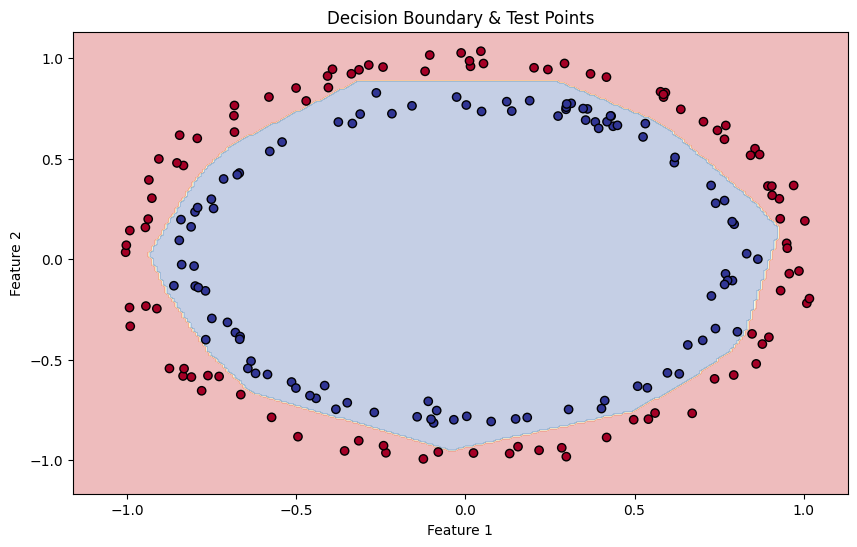

In [ ]:

model.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model(X_test))).squeeze()


X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()


h = 0.01
x_min, x_max = X[:,0].min() - 0.1, X[:,0].max() + 0.1
y_min, y_max = X[:,1].min() - 0.1, X[:,1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))


grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float().to(device)
with torch.inference_mode():
    Z = torch.sigmoid(model(grid))
    Z = torch.round(Z).cpu().numpy().reshape(xx.shape)


plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_test_np[:,0], X_test_np[:,1], c=y_test_np, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.title("Decision Boundary & Test Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
